# Libraries and Params

In [1]:
# Importing libraries
import os
import cv2
import random 
import numpy as np 
import pandas as pd 
import seaborn as sns
from tqdm import tqdm
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.utils import class_weight
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import label_binarize
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, InceptionV3
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, concatenate, Conv2D, MaxPooling2D, Flatten
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc

In [2]:
# Settig parameters
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 1e-4
NUM_CLASSES = 3

# Data Exploration

In [3]:
# Ignoring warning messages
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Loading the dataset CSV files
train = pd.read_csv('/kaggle/input/aptos2019-blindness-detection/train.csv')
train.head()

,id_code,diagnosis
0,000c1434d8d7,2
1,001639a390f0,4
2,0024cdab0c1e,1
3,002c21358ce6,0
4,005b95c28852,0


In [5]:
# Displaying number of samples
print('Number of train samples: ', train.shape[0])

Number of train samples:  3662


In [6]:
print("\nTrain dataset info:")
train.info()


Train dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_code    3662 non-null   object
 1   diagnosis  3662 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 57.3+ KB


In [7]:
print("\nTrain dataset description:")
print(train.describe())


Train dataset description:
         diagnosis
count  3662.000000
mean      1.126980
std       1.298409
min       0.000000
25%       0.000000
50%       1.000000
75%       2.000000
max       4.000000


In [8]:
# Checking missing values
print("Missing Values in Train:\n", train.isnull().sum())

Missing Values in Train:
 id_code      0
diagnosis    0
dtype: int64


In [9]:
# Printing number of images per class
print(train.diagnosis.value_counts())

diagnosis
0    1805
2     999
1     370
4     295
3     193
Name: count, dtype: int64


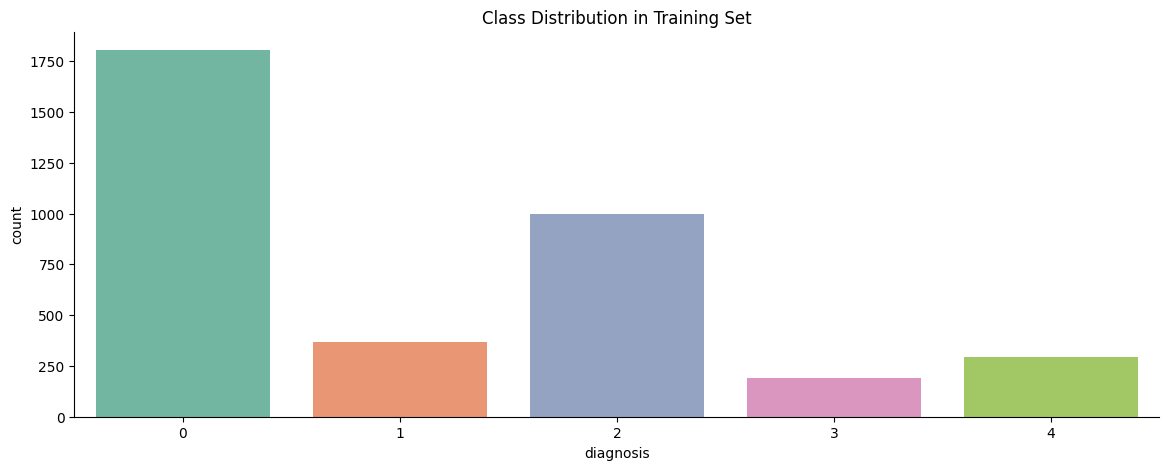

In [10]:
# class distribution in the training set
f, ax = plt.subplots(figsize=(14, 5))
ax = sns.countplot(x="diagnosis", data=train, palette="Set2")
sns.despine()
plt.title("Class Distribution in Training Set")
plt.show()

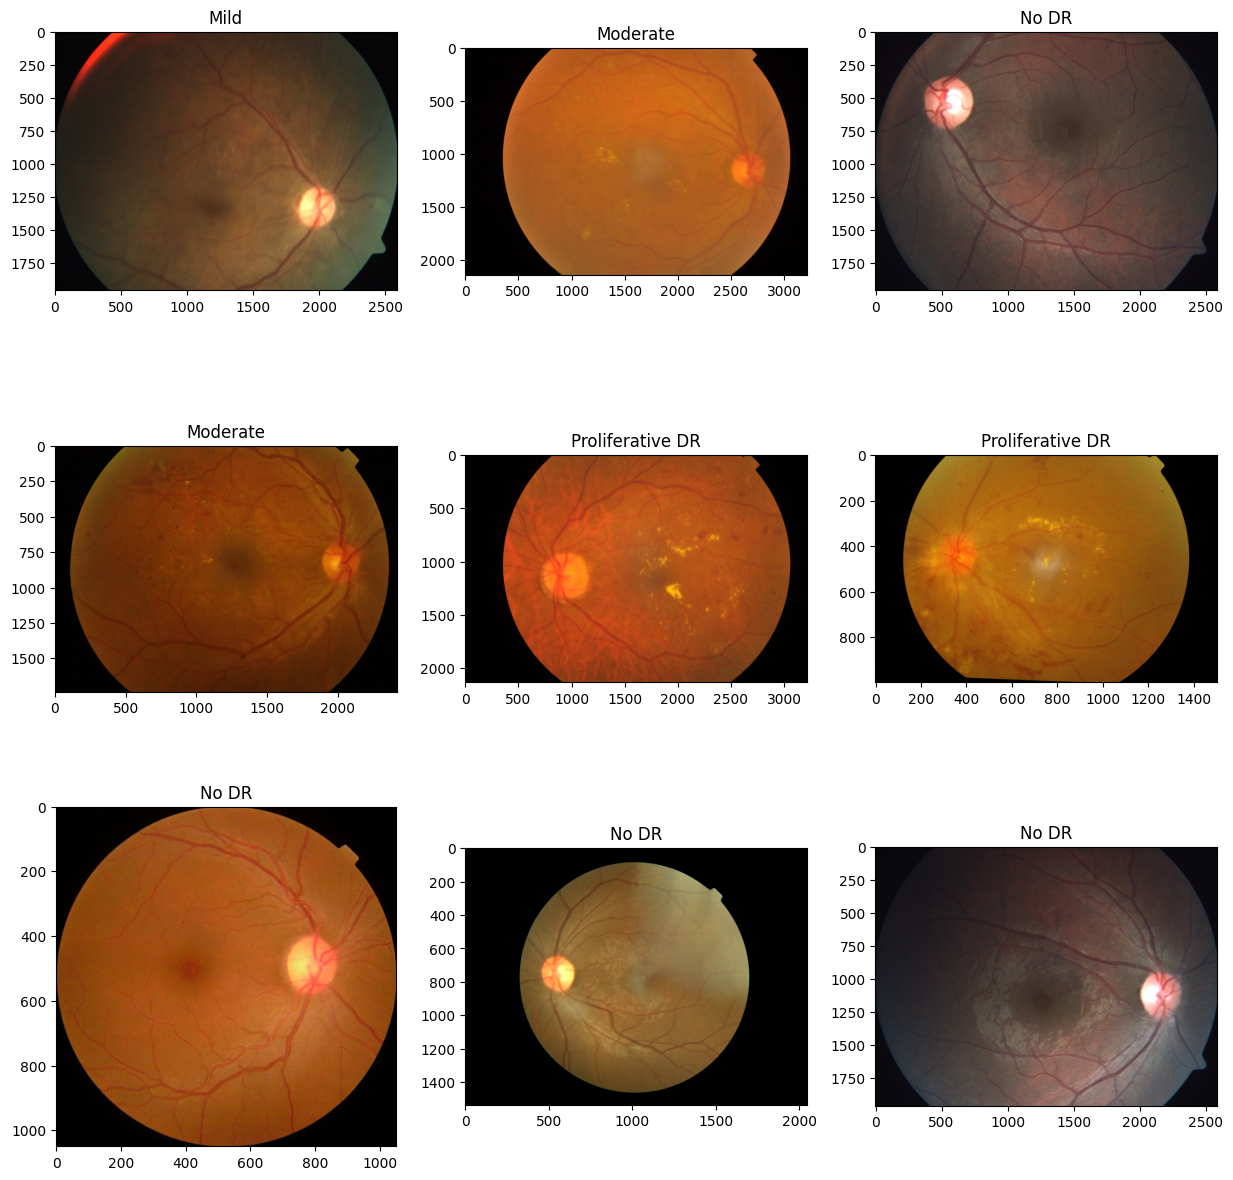

In [11]:
label_dic = {
    "0":"No DR",
    "1" : "Mild",
    "2":"Moderate",
    "3":"Severe",
    "4":"Proliferative DR"
}

rows=3
cols = 3
count = 0
indx = random.sample(range(train.shape[0]),rows * cols)

# Creating figure with multiple cells
fig, axes = plt.subplots(nrows=rows, ncols=cols, figsize=(15,15))

# Iterating all axis and putting image to the,
for i in range(rows):
    for j in range(cols):        
        if count < len(indx):

            # Reading image from path
            img_path = "/kaggle/input/aptos2019-blindness-detection/train_images/"+train.iloc[indx[count],0]+".png"
            img = cv2.imread(img_path)

            # Changing color
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Plotting to the axis
            axes[i, j].imshow(img)
            axes[i,j].set_title(label_dic[str(train.iloc[indx[count],1])])
            count+=1

In [12]:
# Appending '.png' to file names
train["id_code"] = train["id_code"].apply(lambda x: x + ".png")

# Creating Copy
df_origional = train.copy()

# Combining classes into 3 categories
train['diagnosis'] = train['diagnosis'].replace({0: 0, 1: 1, 2: 1, 3: 2, 4: 2})

label_dict = {
    0: 'No Disease',
    1: 'Mild Disease',
    2: 'Severe Disease'
}

class_distribution = train['diagnosis'].value_counts().sort_index()
class_distribution.index = class_distribution.index.map(label_dict)

print("Updated class distribution:\n", class_distribution)

Updated class distribution:
 diagnosis
No Disease        1805
Mild Disease      1369
Severe Disease     488
Name: count, dtype: int64


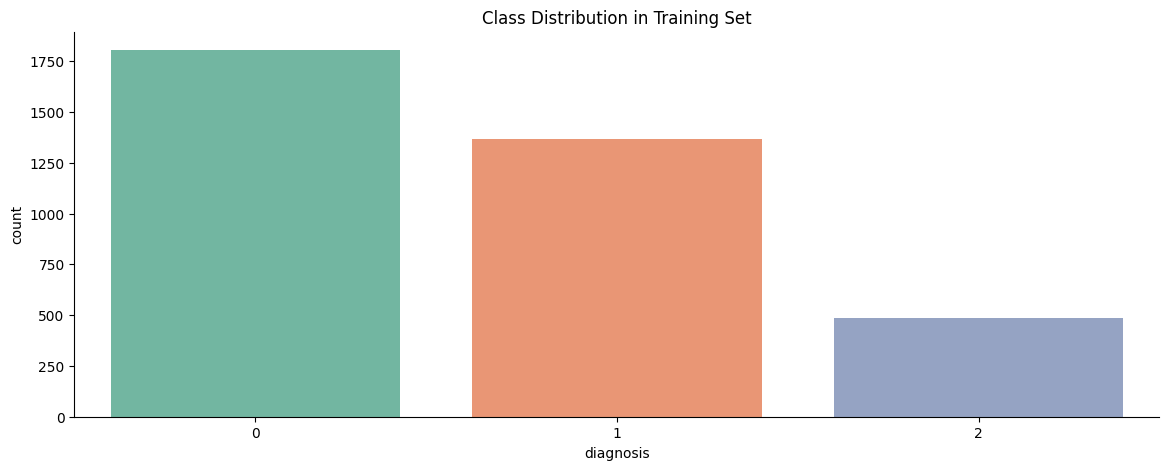

In [13]:
# Bar chart show the distribution of classes
f, ax = plt.subplots(figsize=(14, 5))
ax = sns.countplot(x="diagnosis", data=train, palette="Set2")
sns.despine()
plt.title("Class Distribution in Training Set")
plt.show()

# Images Loading and Processing

In [14]:
X = []
y = []

# Iterating all rows on by one
for i, row in tqdm(train.sample(len(train)).iterrows()):

    # Making image path from image name and base path
    image_name = row.id_code
    image_path = os.path.join("/kaggle/input/aptos2019-blindness-detection/train_images", image_name)
    label = row.diagnosis

    # Read image
    image = cv2.imread(image_path)
    if image is not None:  # Check if image is loaded properly
        # Convert image to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize image to the defined IMAGE_SIZE
        image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

        # Rescale pixel values to the range [0, 1]
        image = image / 255.0

        # Append processed image and label to respective lists
        X.append(image)
        y.append(label)
    else:
        print(f"Image not found or unable to read: {image_path}")

# Convert lists to NumPy arrays
X = np.array(X, dtype='float32')
y = np.array(y, dtype='int32')

print(f"Shape of X (images): {X.shape}")
print(f"Shape of y (labels): {y.shape}")

3662it [06:37,  9.20it/s]


Shape of X (images): (3662, 224, 224, 3)
Shape of y (labels): (3662,)


In [15]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# One-hot encode the labels
y_encoded = to_categorical(y, num_classes=NUM_CLASSES)

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}, y_test: {y_test.shape}")

Shape of X_train: (2929, 224, 224, 3), y_train: (2929, 3)
Shape of X_test: (733, 224, 224, 3), y_test: (733, 3)


In [16]:
# Define the ImageDataGenerator for data augmentation
train_datagen = ImageDataGenerator(
    rotation_range=30,       # Random rotation
    width_shift_range=0.2,   # Horizontal shift
    height_shift_range=0.2,  # Vertical shift
    shear_range=0.2,         # Shearing
    zoom_range=0.2,          # Random zoom
    horizontal_flip=True,    # Horizontal flipping
    fill_mode="nearest"      # Fill mode for empty pixels
)

# Test data generator (no augmentation, only rescaling if needed)
test_datagen = ImageDataGenerator()

# Creating data generators
train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_generator = test_datagen.flow(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Data generators are ready.")

Data generators are ready.


# Unbalanced Data Modeling

## a) Multi Classification Modelling

In [17]:
# Model building function
def build_fusion_model(num_classes, input_shape=(224, 224, 3), dropout_rate=0.5):
    input_layer = Input(shape=input_shape)

    # EfficientNetB0
    efficient_net = EfficientNetB0(include_top=False, input_tensor=input_layer, weights='imagenet')

    i = 0
    for i, layer in enumerate(efficient_net.layers):
      if i < 10:
        layer.trainable = True
        i += 1
      else:
        layer.trainable = False
    efficient_output = GlobalAveragePooling2D()(efficient_net.output)

    # InceptionV3
    inception_v3 = InceptionV3(include_top=False, input_tensor=input_layer, weights='imagenet')
    i = 0
    for i, layer in enumerate(inception_v3.layers):
      if i < 10:
        layer.trainable = True
        i += 1
      else:
        layer.trainable = False
    inception_output = GlobalAveragePooling2D()(inception_v3.output)

    # Concatenate outputs
    combined_output = concatenate([efficient_output, inception_output])

    # Fully connected layers with dropout
    x = Dense(256, activation='relu')(combined_output)
    x = Dropout(dropout_rate)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(dropout_rate)(x)

    # Output Layer
    if num_classes == 2:
        output_layer = Dense(1, activation='sigmoid')(x)
    else:
        output_layer = Dense(NUM_CLASSES, activation='softmax')(x)
        
    model = Model(inputs=input_layer, outputs=output_layer)

    return model

In [18]:
# Building the fusion model
fusion_model = build_fusion_model(input_shape=(224, 224, 3), num_classes=3 , dropout_rate=0.5)

# Compile the model 
fusion_model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='categorical_crossentropy', metrics=['accuracy'])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [19]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Function to create callbacks
def create_callbacks(checkpoint_path):
    # Create a ModelCheckpoint callback
    checkpoint_callback = ModelCheckpoint(
        filepath=checkpoint_path,  # Path to save the model
        monitor='val_loss',       # Metric to monitor
        save_best_only=True,      # Save only the best model
        mode='min',               # Mode to minimize val_loss
        verbose=1                 # Print saving details
    )

    return checkpoint_callback

# Creating callbacks
checkpoint_path = "best_fusion_model.keras"
checkpoint_callback = create_callbacks(checkpoint_path)

In [20]:
# Training the model 
history = fusion_model.fit(train_generator, 
                           validation_data=test_generator, 
                           epochs=EPOCHS,
                           callbacks=[checkpoint_callback]
                          )

Epoch 1/15


I0000 00:00:1736686004.362859      72 service.cc:145] XLA service 0x798ac40ae1d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1736686004.362958      72 service.cc:153]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


 1/92 ━━━━━━━━━━━━━━━━━━━━ 1:28:53 59s/step - accuracy: 0.2812 - loss: 1.4684

I0000 00:00:1736686043.919608      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 674ms/step - accuracy: 0.5079 - loss: 1.0978
Epoch 1: val_loss improved from inf to 0.83780, saving model to best_fusion_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 141s 909ms/step - accuracy: 0.5088 - loss: 1.0956 - val_accuracy: 0.6057 - val_loss: 0.8378
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.7313 - loss: 0.6688
Epoch 2: val_loss improved from 0.83780 to 0.78888, saving model to best_fusion_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 315ms/step - accuracy: 0.7315 - loss: 0.6683 - val_accuracy: 0.6221 - val_loss: 0.7889
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 287ms/step - accuracy: 0.7589 - loss: 0.5793
Epoch 3: val_loss improved from 0.78888 to 0.72887, saving model to best_fusion_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 320ms/step - accuracy: 0.7590 - loss: 0.5790 - val_accuracy: 0.6658 - val_loss: 0.7289
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.7718 - loss: 0.5354
Epoch 4: val_loss improved from 0.72887 

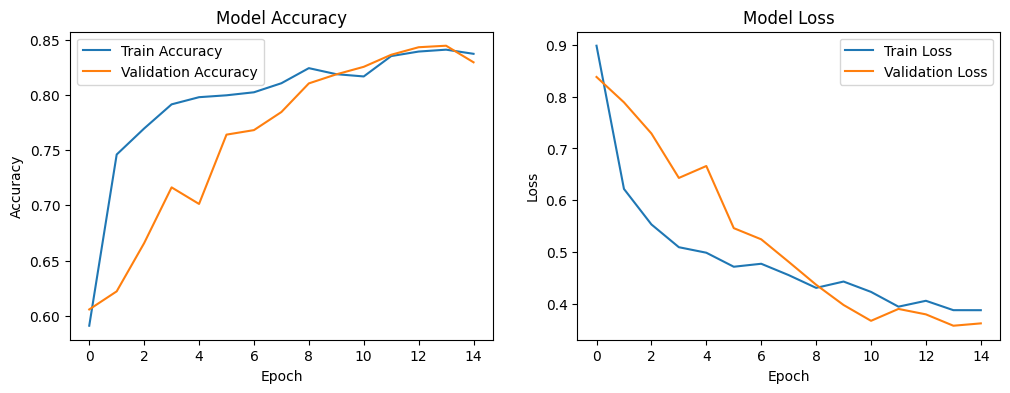

In [21]:
def plot_history(history):
    # Plotting the training and validation accuracy/loss
    plt.figure(figsize=(12, 4))
    
    # Plotting Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    # Plotting Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.show()


# Plotting history
plot_history(history)

In [22]:
# Getting true labels and predictions
y_true = y_test.argmax(axis=1)
y_pred = np.argmax(fusion_model.predict(X_test), axis=1)
class_labels = list(label_dict.values())

23/23 ━━━━━━━━━━━━━━━━━━━━ 19s 479ms/step


In [23]:
def evaluate_model(y_true, y_pred, class_labels):
    # Calculating accuracy, precision, recall, and F1 score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)

    # Displaying classification report
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=class_labels))

    # Generating and ploting the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

    if len(class_labels) == 2:
        # Plotting the ROC curve for each class
        y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
        n_classes = y_true_bin.shape[1]
        y_pred_bin = label_binarize(y_pred, classes=[0, 1, 2])
        plt.figure(figsize=(10, 6))
        for i in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_bin[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'Class {label_dict[i]} (AUC = {roc_auc:.2f})')
        
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve for Each Class')
        plt.legend(loc='lower right')
        plt.show()

Accuracy: 0.8294679399727148
Precision: 0.8241116371682146
Recall: 0.8294679399727148
F1 Score: 0.8034171501003142
Classification Report:
                 precision    recall  f1-score   support

    No Disease       0.92      0.98      0.95       361
  Mild Disease       0.73      0.86      0.79       274
Severe Disease       0.73      0.19      0.31        98

      accuracy                           0.83       733
     macro avg       0.79      0.68      0.68       733
  weighted avg       0.82      0.83      0.80       733



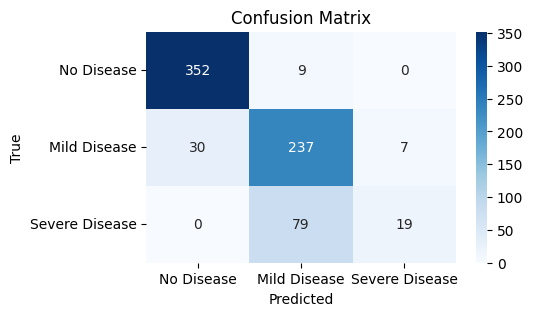

In [24]:
evaluate_model(y_true, y_pred, class_labels)

## b) Binary Classification Modelling

In [25]:
y_binary = [0 if i==0 else 1 for i in y]

# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42, stratify=y)

# Creating data generators
train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_generator = test_datagen.flow(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Data generators are ready.")

Data generators are ready.


In [26]:
# Building the fusion model
fusion_model = build_fusion_model(input_shape=(224, 224, 3), num_classes=2, dropout_rate=0.5)

# Compile the model 
fusion_model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='binary_crossentropy', metrics=['accuracy'])

In [27]:
# Creating callbacks
checkpoint_path = "best_fusion_model.keras"
checkpoint_callback = create_callbacks(checkpoint_path)

In [28]:
# Training the model 
history = fusion_model.fit(train_generator, 
                           validation_data=test_generator, 
                           epochs=EPOCHS,
                           callbacks=[checkpoint_callback]
                          )

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 591ms/step - accuracy: 0.6707 - loss: 0.5983
Epoch 1: val_loss improved from inf to 0.43846, saving model to best_fusion_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 121s 774ms/step - accuracy: 0.6718 - loss: 0.5970 - val_accuracy: 0.8281 - val_loss: 0.4385
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.8973 - loss: 0.2899
Epoch 2: val_loss improved from 0.43846 to 0.42341, saving model to best_fusion_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 321ms/step - accuracy: 0.8974 - loss: 0.2897 - val_accuracy: 0.8063 - val_loss: 0.4234
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step - accuracy: 0.9158 - loss: 0.2167
Epoch 3: val_loss improved from 0.42341 to 0.32230, saving model to best_fusion_model.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 32s 320ms/step - accuracy: 0.9159 - loss: 0.2166 - val_accuracy: 0.8799 - val_loss: 0.3223
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - accuracy: 0.9320 - loss: 0.1930
Epoch 4: val_loss did not imp

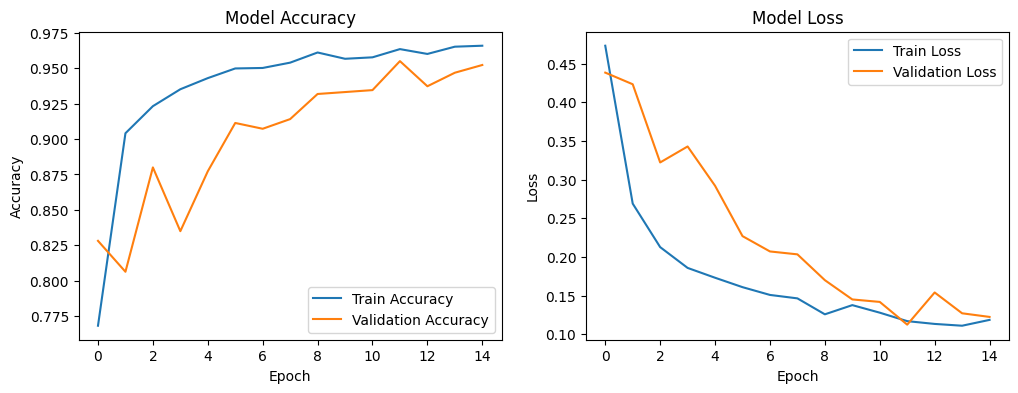

In [29]:
# Plotting history
plot_history(history)

23/23 ━━━━━━━━━━━━━━━━━━━━ 20s 464ms/step
Accuracy: 0.9522510231923602
Precision: 0.9530384343223807
Recall: 0.9522510231923602
F1 Score: 0.9522456908220224
Classification Report:
               precision    recall  f1-score   support

       No DR       0.93      0.97      0.95       361
          DR       0.97      0.93      0.95       372

    accuracy                           0.95       733
   macro avg       0.95      0.95      0.95       733
weighted avg       0.95      0.95      0.95       733



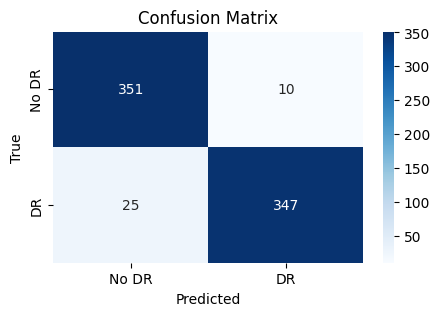

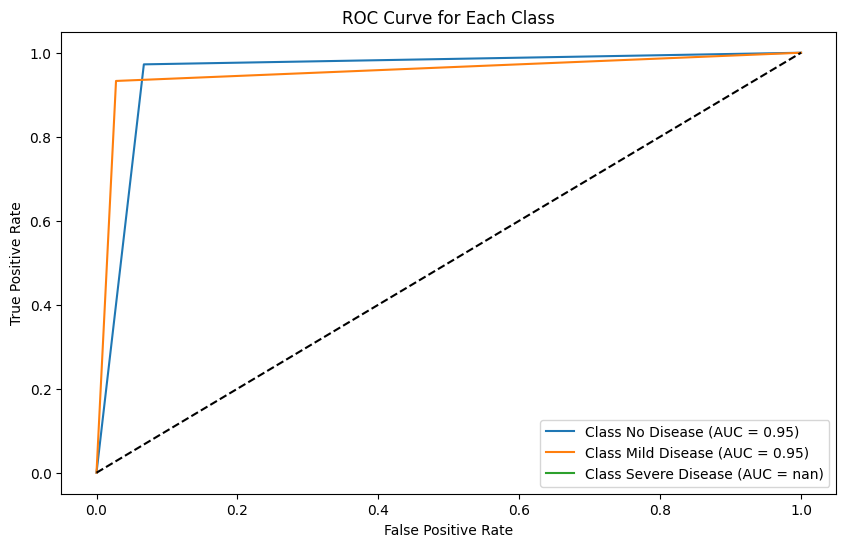

In [30]:
# Getting true labels and predictions
y_true = y_test
y_pred = [0 if i<0.5 else 1 for i in fusion_model.predict(X_test)]
class_labels = ["No DR", "DR"]
evaluate_model(y_true, y_pred, class_labels)

## c) No DR vs Severe Class Modelling

In [31]:
# Combining classes into 3 categories
df_binary = df_origional[df_origional.diagnosis.isin([0, 4])]
df_binary.replace({4: 1}, inplace=True)

X_binary = []
y_binary = []

for i, row in tqdm(df_binary.sample(len(df_binary)).iterrows()):
    image_name = row.id_code
    image_path = os.path.join("/kaggle/input/aptos2019-blindness-detection/train_images", image_name)
    label = row.diagnosis

    # Read image
    image = cv2.imread(image_path)
    if image is not None:  # Check if image is loaded properly
        # Convert image to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Resize image to the defined IMAGE_SIZE
        image = cv2.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

        # Rescale pixel values to the range [0, 1]
        image = image / 255.0

        # Append processed image and label to respective lists
        X_binary.append(image)
        y_binary.append(label)
    else:
        print(f"Image not found or unable to read: {image_path}")

# Convert lists to NumPy arrays
X_binary = np.array(X_binary, dtype='float32')
y_binary = np.array(y_binary, dtype='int32')

print(f"Shape of X (images): {X_binary.shape}")
print(f"Shape of y (labels): {y_binary.shape}")

2100it [02:29, 14.02it/s]


Shape of X (images): (2100, 224, 224, 3)
Shape of y (labels): (2100,)


In [32]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_binary, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

print(f"Shape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}, y_test: {y_test.shape}")

Shape of X_train: (1680, 224, 224, 3), y_train: (1680,)
Shape of X_test: (420, 224, 224, 3), y_test: (420,)


In [33]:
# Creating data generators
train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_generator = test_datagen.flow(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Data generators are ready.")

Data generators are ready.


In [34]:
# Building the fusion model
fusion_model = build_fusion_model(input_shape=(224, 224, 3), num_classes=2, dropout_rate=0.5)

# Compile the model 
fusion_model.compile(optimizer=Adam(learning_rate=LEARNING_RATE), loss='binary_crossentropy', metrics=['accuracy'])

In [35]:
# Creating callbacks
checkpoint_path = "best_fusion_model.keras"
checkpoint_callback = create_callbacks(checkpoint_path)

In [36]:
# Training the model 
history = fusion_model.fit(train_generator, 
                           validation_data=test_generator, 
                           epochs=EPOCHS,
                           callbacks=[checkpoint_callback]
                          )

Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 964ms/step - accuracy: 0.7608 - loss: 0.5813
Epoch 1: val_loss improved from inf to 0.31836, saving model to best_fusion_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 119s 1s/step - accuracy: 0.7623 - loss: 0.5783 - val_accuracy: 0.8595 - val_loss: 0.3184
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step - accuracy: 0.8875 - loss: 0.2696
Epoch 2: val_loss improved from 0.31836 to 0.25175, saving model to best_fusion_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 318ms/step - accuracy: 0.8877 - loss: 0.2690 - val_accuracy: 0.8810 - val_loss: 0.2517
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step - accuracy: 0.9288 - loss: 0.1559
Epoch 3: val_loss improved from 0.25175 to 0.19550, saving model to best_fusion_model.keras
53/53 ━━━━━━━━━━━━━━━━━━━━ 19s 324ms/step - accuracy: 0.9289 - loss: 0.1559 - val_accuracy: 0.9262 - val_loss: 0.1955
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.9505 - loss: 0.1279
Epoch 4: val_loss improved from 

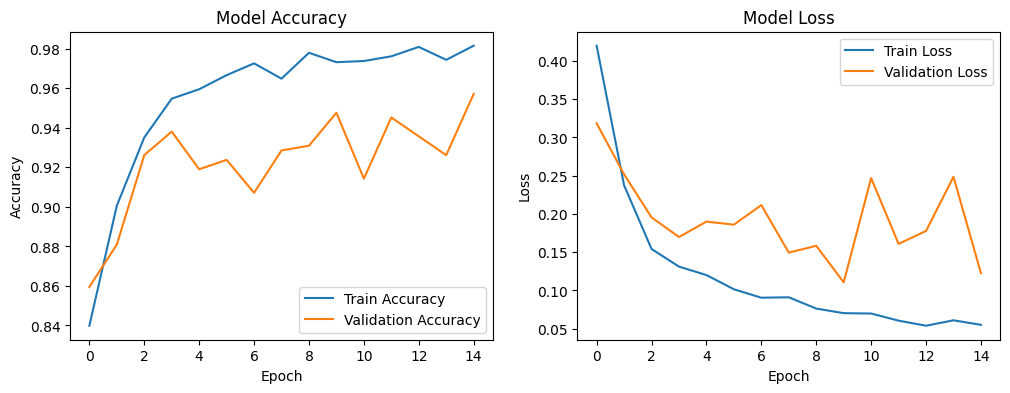

In [37]:
# Plotting history
plot_history(history)

14/14 ━━━━━━━━━━━━━━━━━━━━ 18s 735ms/step
Accuracy: 0.9571428571428572
Precision: 0.9591782887297399
Recall: 0.9571428571428572
F1 Score: 0.9538069498069498
Classification Report:
               precision    recall  f1-score   support

       No DR       0.95      1.00      0.98       361
   Severe DR       1.00      0.69      0.82        59

    accuracy                           0.96       420
   macro avg       0.98      0.85      0.90       420
weighted avg       0.96      0.96      0.95       420



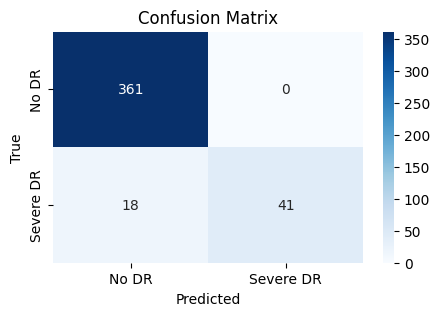

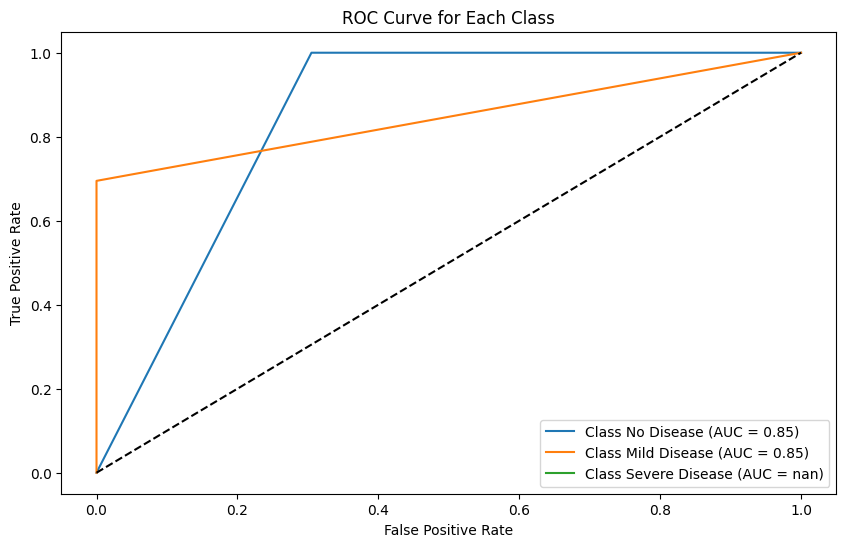

In [38]:
# Getting true labels and predictions
y_true = y_test
y_pred = [0 if i<0.5 else 1 for i in fusion_model.predict(X_test)]
class_labels = ["No DR", "Severe DR"]
evaluate_model(y_true, y_pred, class_labels)

In [39]:
# Deleting lists to free-up memory
del(X_binary)
del(y_binary)

# Balanced Data Modelling

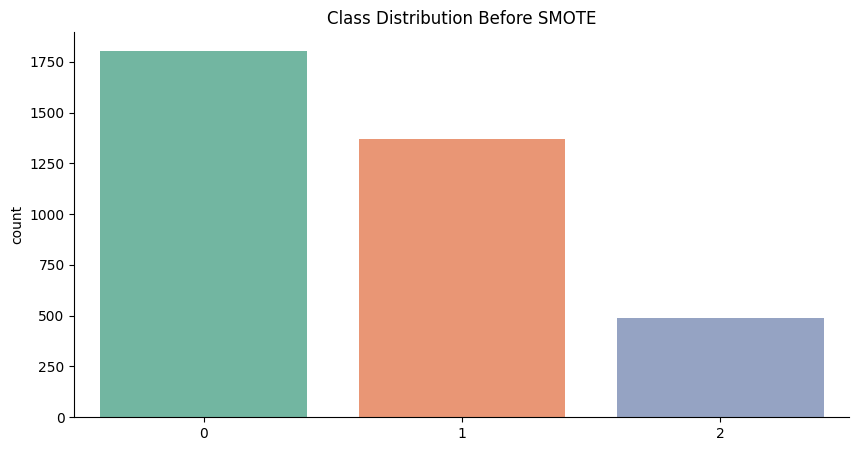

In [40]:
from imblearn.over_sampling import SMOTE

# Plot class distribution before SMOTE
plt.figure(figsize=(10, 5))
plt.title("Class Distribution Before SMOTE")
sns.countplot(x=y, palette="Set2")
sns.despine()
plt.show()

In [41]:
print("Number of records before SMOTE: ", len(y))

Number of records before SMOTE:  3662


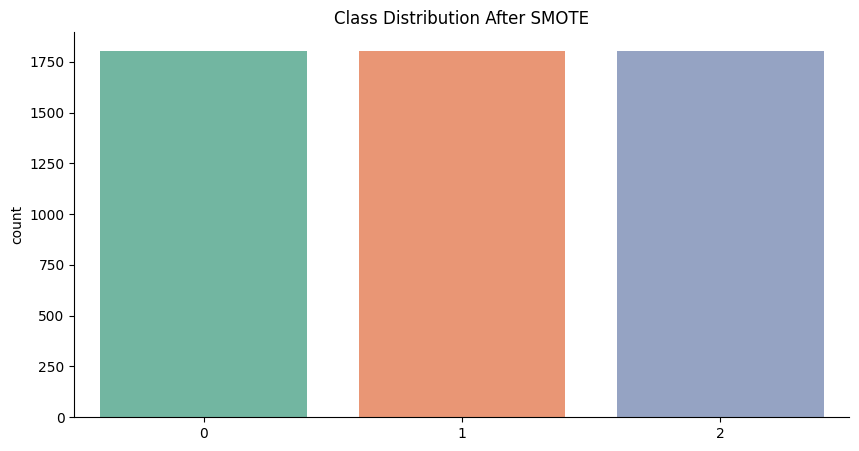

In [42]:
# SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X.reshape(X.shape[0], -1), y)

# Plot class distribution after SMOTE
plt.figure(figsize=(10, 5))
plt.title("Class Distribution After SMOTE")
sns.countplot(x=y_smote, palette="Set2")
sns.despine()
plt.show()

In [43]:
print("Number of records after SMOTE: ", len(y_smote))
print("New generated Samples: ", len(y_smote)-len(y))

Number of records after SMOTE:  5415
New generated Samples:  1753


In [44]:
# Reshape X_smote back to original image dimensions
X_smote = X_smote.reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 3)

# Encode updated y using one-hot encoding
y_smote_encoded = to_categorical(y_smote, num_classes=NUM_CLASSES)

# Split the balanced dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote_encoded, test_size=0.2, random_state=42, stratify=y_smote
)

print(f"Shape of X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}, y_test: {y_test.shape}")

Shape of X_train: (4332, 224, 224, 3), y_train: (4332, 3)
Shape of X_test: (1083, 224, 224, 3), y_test: (1083, 3)


In [45]:
# Creating data generators
train_generator = train_datagen.flow(
    X_train, y_train,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_generator = test_datagen.flow(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Balanced data generators are ready.")


Balanced data generators are ready.


In [46]:
# Building the fusion model
balanced_fusion_model = build_fusion_model(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), 
    num_classes= NUM_CLASSES , 
    dropout_rate=0.5
)

# Compile the model 
balanced_fusion_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

In [47]:
# Creating callbacks
checkpoint_path = "best_balanced_fusion_model.keras"
checkpoint_callback = create_callbacks(checkpoint_path)

In [48]:
# Training the model 
history_balanced = balanced_fusion_model.fit(train_generator, 
                           validation_data=test_generator, 
                           epochs=EPOCHS,
                           callbacks=[checkpoint_callback]
                          )

Epoch 1/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.4515 - loss: 1.1270
Epoch 1: val_loss improved from inf to 0.86650, saving model to best_balanced_fusion_model.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 145s 719ms/step - accuracy: 0.4521 - loss: 1.1257 - val_accuracy: 0.5734 - val_loss: 0.8665
Epoch 2/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.6374 - loss: 0.7350
Epoch 2: val_loss improved from 0.86650 to 0.75275, saving model to best_balanced_fusion_model.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 46s 322ms/step - accuracy: 0.6374 - loss: 0.7348 - val_accuracy: 0.6584 - val_loss: 0.7528
Epoch 3/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step - accuracy: 0.6738 - loss: 0.6575
Epoch 3: val_loss improved from 0.75275 to 0.74175, saving model to best_balanced_fusion_model.keras
136/136 ━━━━━━━━━━━━━━━━━━━━ 46s 322ms/step - accuracy: 0.6739 - loss: 0.6573 - val_accuracy: 0.6464 - val_loss: 0.7417
Epoch 4/15
136/136 ━━━━━━━━━━━━━━━━━━━━ 0s 295ms/step - accuracy: 0.7097 - l

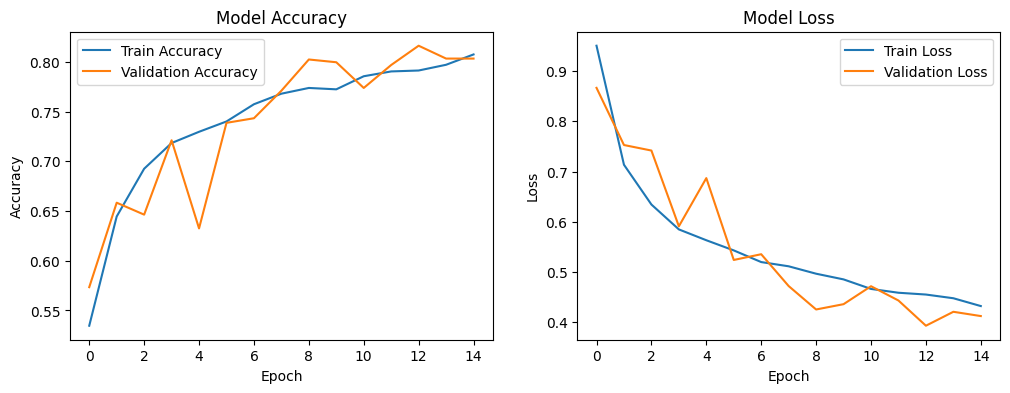

In [49]:
# Plotting history
plot_history(history_balanced)

34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 340ms/step
Accuracy: 0.8033240997229917
Precision: 0.8220499378705071
Recall: 0.8033240997229917
F1 Score: 0.7996434480741946
Classification Report:
                 precision    recall  f1-score   support

    No Disease       0.91      0.98      0.94       361
  Mild Disease       0.67      0.83      0.74       361
Severe Disease       0.89      0.60      0.72       361

      accuracy                           0.80      1083
     macro avg       0.82      0.80      0.80      1083
  weighted avg       0.82      0.80      0.80      1083



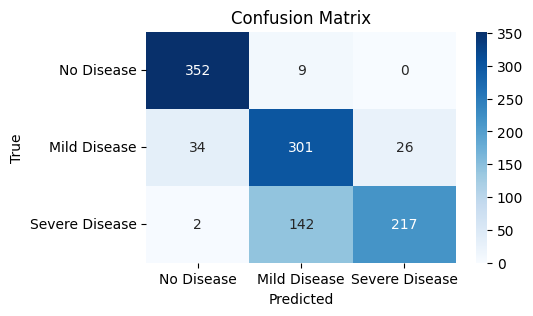

In [50]:
# Getting true labels and predictions
y_true = y_test.argmax(axis=1)
y_pred = np.argmax(balanced_fusion_model.predict(X_test), axis=1)
class_labels = list(label_dict.values())

evaluate_model(y_true, y_pred, class_labels)